# Figure4

In [1]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import matplotlib.colors as mcolors
from matplotlib import rcParams, rcParamsDefault
from matplotlib.lines import Line2D
from src.utils.tools import seed_everything

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# sns.set_palette("colorblind")
# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
# COLOR_MAP = {'H3K4me1':'#40A878','H3K4me3':'#86A1C0','H3K9me3':'#EEDCAD','H3K27ac':'#B09324','H3K27me3':'#498FC7','H3K36me3':'#A074A9','H3K9ac':'#D87469'}
COLOR_MAP = {'H3K9ac':'#5F7BB0','H3K27ac':'#E6867D','H3K4me3':'#77BBDE','H3K4me1':'#C189B3','H3K36me3':'#9AC984','H3K27me3':'#ECDC6B','H3K9me3':'#91CDC6'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)


# Figure 4B

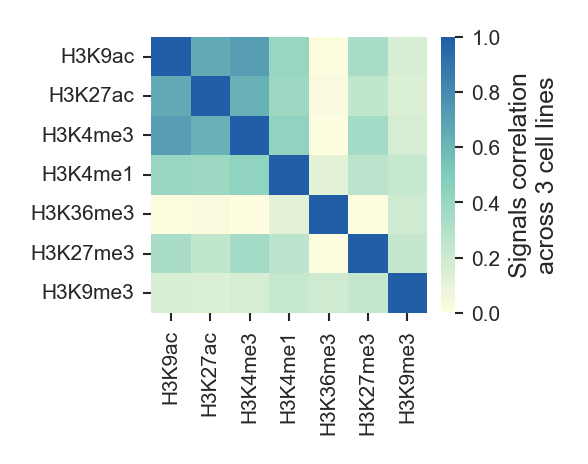

In [29]:
eid = 'E003'
# correlation
correlation_E003 = np.loadtxt(f'extra/datasets/benchmark/Promoterformer/results/{eid}_hm_correlation.csv',delimiter=",")
eid = 'E116'
# correlation
correlation_E116 = np.loadtxt(f'extra/datasets/benchmark/Promoterformer/results/{eid}_hm_correlation.csv',delimiter=",")
eid = 'E118'
# correlation
correlation_E118 = np.loadtxt(f'extra/datasets/benchmark/Promoterformer/results/{eid}_hm_correlation.csv',delimiter=",")

correlation = (correlation_E003+correlation_E116+correlation_E118)/3
# 选择第 0 个样本的行间相关性矩阵
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4.7/2.54, 4.7/2.54))
ax = sns.heatmap(correlation,cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=0, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100))
ax.set_xticklabels(MARKS,rotation=90)
ax.set_yticklabels(MARKS,rotation=360)
ax.set_aspect('equal')
ax.tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
cbar = ax.collections[0].colorbar

# 调整colorbar的刻度粗细
cbar.ax.tick_params(width=0.5,labelsize=5)  # 设置colorbar刻度的粗细
cbar.set_label(f'Signals correlation\nacross 3 cell lines',fontsize=6)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Figure4B.eps', format='eps', bbox_inches='tight')
plt.show()


# Figure 4B

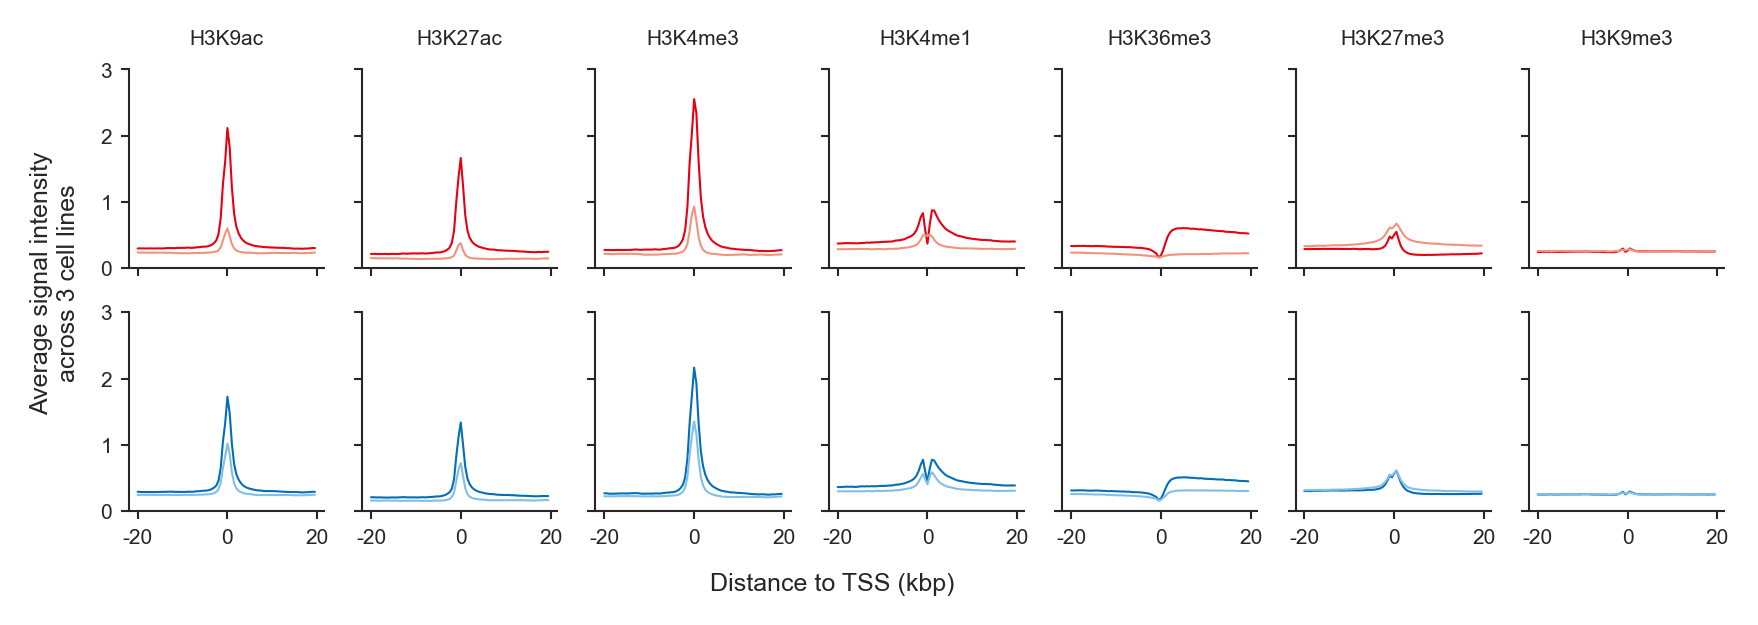

In [7]:

fig, ax = plt.subplots(2, 7, constrained_layout=True, figsize=(14/2.54, 5/2.54))
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = ['H3K9ac', 'H3K27ac','H3K4me3','H3K4me1' ,'H3K36me3','H3K27me3','H3K9me3']

eid = 'E003'
high_marks_E003 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_para_highmarks.npy")
low_marks_E003 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_para_lowmarks.npy")

eid = 'E116'
high_marks_E116 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_para_highmarks.npy")
low_marks_E116 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_para_lowmarks.npy")

eid = 'E118'
high_marks_E118 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_para_highmarks.npy")
low_marks_E118 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_para_lowmarks.npy")

high_marks = (high_marks_E003 + high_marks_E116 + high_marks_E118) / 3
low_marks = (low_marks_E003 + low_marks_E116 + low_marks_E118) / 3

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='#E60012',  ax=ax[0, idx],linewidth=0.5)
    sns.lineplot(low_marks[_idx], color='#F1937C',  ax=ax[0, idx],linewidth=0.5)
    # Set the y-axis ticks
    ax[0, idx % 7].set_yticks([i * 0.1 for i in range(0, 31, 10)])
    ax[0, idx % 7].set_xticks([i for i in range(0, 81, 40)],labels=[int((i-40)/2) for i in range(0, 81, 40)])
    if idx == 0:
        ax[0, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False)
    else:
        ax[0, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False,labelleft=False)
    # Set the title for each subplot
    ax[0, idx % 7].set_title(mark, fontsize=5)
    ax[0, idx % 7].set_ylim(ymax=3)
    # Set the xlabel for each subplot

lines = ax[0,0].get_lines()

handles0 = [lines[0], lines[1]]
labels0  = ["$BF^+$","$BF^-$"]

eid = 'E003'
high_marks_E003 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_para_highmarks.npy")
low_marks_E003 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_para_lowmarks.npy")

eid = 'E116'
high_marks_E116 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_para_highmarks.npy")
low_marks_E116 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_para_lowmarks.npy")

eid = 'E118'
high_marks_E118 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_para_highmarks.npy")
low_marks_E118 = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_para_lowmarks.npy")

high_marks = (high_marks_E003 + high_marks_E116 + high_marks_E118) / 3
low_marks = (low_marks_E003 + low_marks_E116 + low_marks_E118) / 3

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='#036EB8',  ax=ax[1, idx],linewidth=0.5)
    sns.lineplot(low_marks[_idx], color='#81BEE8',  ax=ax[1, idx],linewidth=0.5)
    # Set the y-axis ticks
    ax[1, idx % 7].set_yticks([i * 0.1 for i in range(0, 31, 10)])
    ax[1, idx % 7].set_xticks([i for i in range(0, 81, 40)],labels=[int((i-40)/2) for i in range(0, 81, 40)])
    if idx == 0:
        ax[1, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=True)
    else:
        ax[1, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=True,labelleft=False)

    ax[1, idx % 7].set_ylim(ymax=3)
    # Set the xlabel for each subplot

lines = ax[1,0].get_lines()

handles1 = [lines[0], lines[1]]
labels1 = ["$BS^+$","$BS^-$"]

ax[0,0].set_ylabel('',fontsize=5)
ax[1,0].set_ylabel('',fontsize=5)
# ax[0,6].legend(handles0, labels0,loc='upper left', bbox_to_anchor=(1.0, 1.15) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')
# ax[1,6].legend(handles1, labels1,loc='upper left', bbox_to_anchor=(1.0, 1.15) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

fig.supxlabel("Distance to TSS (kbp)",fontsize=6,x=0.45)
fig.supylabel(f"Average signal intensity\nacross 3 cell lines",fontsize=6,x=-0.02 ,y=0.55,ha='center')
# Adjust layout to ensure everything fits


plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Supplementary_Figure3_4.eps', format='eps', bbox_inches='tight')

plt.show()


# Figure 4A

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/1343802290.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/1343802290.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


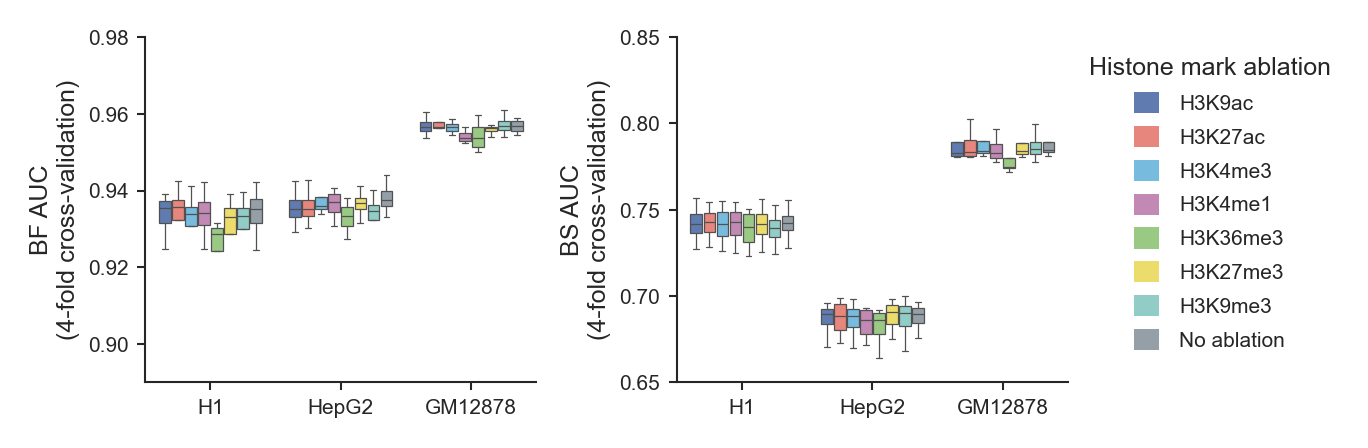

In [11]:
fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(9/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["remove_H3K9ac","remove_H3K27ac","remove_H3K4me3","remove_H3K4me1","remove_H3K36me3","remove_H3K27me3","remove_H3K9me3","all_marks"],name='marks')
palette = {k:COLOR_MAP[k.split('_')[1]] for k in hue_order if k.split('_')[1] in COLOR_MAP}
palette['all_marks'] = '#949FA7'

data =  pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ablation_bf_para.csv',sep='\t')
data['auc'] = data['auc'] / 100



sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.1,width=0.8,order=order,hue_order=hue_order,linewidth=0.3,fliersize=0,
                 palette=palette,ax=ax[0],saturation=1)
ax[0].legend().remove()  # Moves the legend outside the plot
ax[0].set_ylabel('BF AUC\n(4-fold cross-validation)')
ax[0].set_xlabel('')
# ax[0].set_title('Burst frequency',fontsize=6,fontweight='regular')
ax[0].set_ylim(0.89,0.98)
yticks = [i/100 for i in range(90, 99, 2)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)

data =  pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ablation_bs_para.csv',sep='\t')
data['auc'] = data['auc'] / 100

sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.1,width=0.8,order=order,hue_order=hue_order,linewidth=0.3,fliersize=0,
                 palette=palette,ax=ax[1],saturation=1)

ax[1].legend().remove()  # Moves the legend outside the plot
ax[1].set_ylabel('BS AUC\n(4-fold cross-validation)')
ax[1].set_xlabel('')
ax[1].set_ylim(0.65,0.85)
yticks = [i / 100 for i in range(65, 86, 5)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)
# ax[1].set_title('Burst size',fontsize=6,fontweight='regular')


handles, labels = ax[0].get_legend_handles_labels()
# ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac","None"]
labels = ["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3","No ablation"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
legend = fig.legend(handles, labels, 
                    loc='upper left',
                    bbox_to_anchor=(0.99, 0.95), 
                    title_fontsize=6,
                    title='Histone mark ablation',
                    fontsize=5,
                    ncol=1,
                    edgecolor='none',
                    handleheight=3/2.54, 
                    handlelength=3/2.54,
                    handletextpad=1.0,
                    labelspacing=1.5/2.54
                )


for handle in legend.legend_handles:
    if hasattr(handle, 'set_edgecolor'):
        handle.set_edgecolor('none')  # 柱状色块边框
    if hasattr(handle, 'set_linewidth'):
        handle.set_linewidth(0)

ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
# fig.supxlabel('EID')

plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4A.eps', format='eps', bbox_inches='tight')

plt.show()

# Figure 4D

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/575737495.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/575737495.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


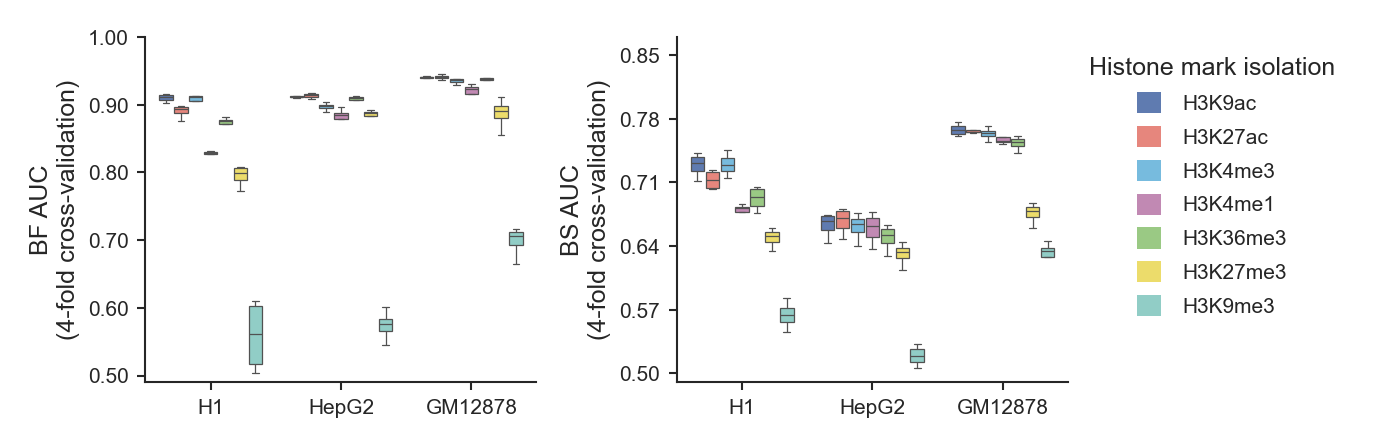

In [12]:
fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(9/2.54, 3.5/2.54))

## BS & BF
data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_bf_para.csv')
data['auc'] = data['auc'] / 100

hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
sns.boxplot(data=data,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,order=order,hue_order=hue_order,linewidth=0.3,fliersize=0,
                 palette=COLOR_MAP,ax=ax[0],saturation=1)
ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].set_ylabel('BF AUC\n(4-fold cross-validation)')
# ax[0].set_title('Burst frequency',fontsize=6,fontweight='regular')
ax[0].set_xlabel('')
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_ylim(0.49,0.92)
yticks = [i/100 for i in range(50, 101, 10)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)


data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_bs_para.csv')
data['auc'] = data['auc'] / 100

hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
# sns.boxplot(data=data,y='auc',x='eid',hue='keep_mark',
#                  gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
#                  palette=COLOR_MAP,ax=ax[1])

sns.boxplot(data=data,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,order=order,hue_order=hue_order,linewidth=0.3,fliersize=0,
                 palette=COLOR_MAP,ax=ax[1],saturation=1)

ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_ylabel('BS AUC\n(4-fold cross-validation)')
# ax.set_ylim(top=4)
ax[1].set_xlabel('')
# ax[1].set_title('Burst size',fontsize=6,fontweight='regular')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_ylim(0.49,0.87)
yticks = [i/100 for i in range(50, 88, 7)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)



handles, labels = ax[0].get_legend_handles_labels()
legend = fig.legend(handles, labels, 
                    loc='upper left',
                    bbox_to_anchor=(0.99, 0.95), 
                    title_fontsize=6,
                    title='Histone mark isolation',
                    fontsize=5,
                    ncol=1,
                    edgecolor='none',
                    handleheight=3/2.54, 
                    handlelength=3/2.54,
                    handletextpad=1.0,
                    labelspacing=1.5/2.54,
                )


for handle in legend.legend_handles:
    if hasattr(handle, 'set_edgecolor'):
        handle.set_edgecolor('none')  # 柱状色块边框
    if hasattr(handle, 'set_linewidth'):
        handle.set_linewidth(0)

plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4C.eps', format='eps', bbox_inches='tight')

plt.show()

# Figure 4E

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/601338583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[0],palette=palette,saturation=1)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/601338583.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[1],palette=palette,saturation=1)
No artists with labels found to put in legend.  Note that artists whose label start wit

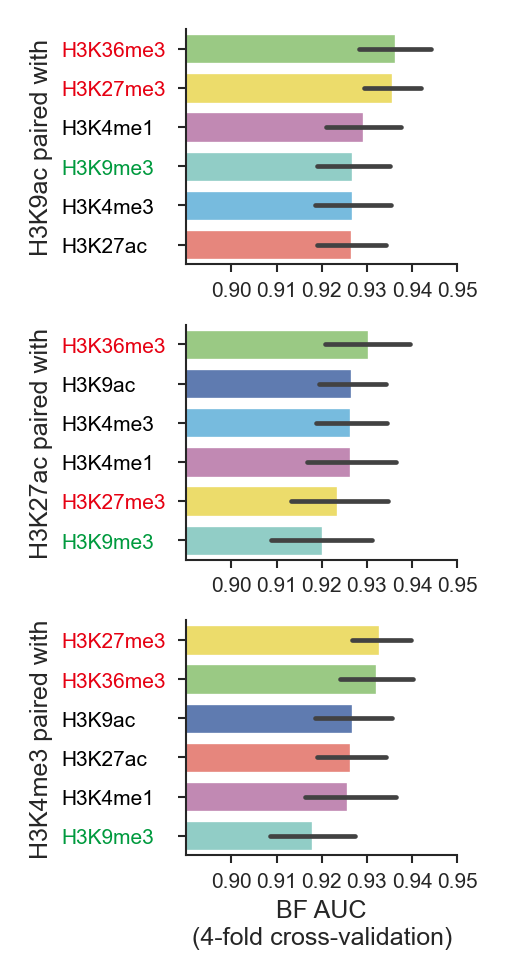

In [24]:
data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
data['auc'] = data['auc'] / 100
# repressive_marks = ['H3K9me3','H3K4me1','H3K27me3','H3K36me3','H3K4me3']
fig, ax = plt.subplots(3,1, constrained_layout=True, figsize=(4/2.54, 8/2.54))
keep_mark = 'H3K9ac'

# data = data[(data['target'] == 'bf_label') &(data['keep_marks'].str.contains(keep_marks))]
data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))]
def _func(row, target_mark):
    marks = row['keep_marks'].split('_')
    marks.remove(target_mark)
    return marks[0]

data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark),axis=1)



sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
palette = [COLOR_MAP[mark] for mark in ['H3K36me3','H3K27me3','H3K4me1','H3K9me3','H3K4me3','H3K27ac']]
# 绘制 barplot，并按照排序后的 keep_marks 显示
sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[0],palette=palette,saturation=1)
ax[0].set_xlim(0.89, 0.95)
xticks = [i / 100 for i in range(90,96,1)]
xticklabels = [f"{i:.2f}" for i in xticks]
ax[0].set_xticks(xticks, labels=xticklabels)
ax[0].set_yticks(sorted_keep_marks)
ax[0].set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax[0].tick_params(axis='y', pad=28)  # 控制文字与坐标轴的间距，单位是点
ax[0].set_ylabel(f"{keep_mark} paired with",fontsize=6)
# ax[0].set_xlabel('AUC of burst frequency\n(4-fold CV)',fontsize=6)
ax[0].set_xlabel('')
ax[0].legend().remove()

label_colors=['#E60012','#E60012','black','#009A3E','black','black']
for label, color in zip(ax[0].get_yticklabels(),label_colors):
    label.set_color(color)


data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
data['auc'] = data['auc'] / 100
keep_mark = 'H3K27ac'

# data = data[(data['target'] == 'bf_label') &(data['keep_marks'].str.contains(keep_marks))]
data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))]
data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark),axis=1)

sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
# 绘制 barplot，并按照排序后的 keep_marks 显示
palette = [COLOR_MAP[mark] for mark in ['H3K36me3','H3K9ac','H3K4me3','H3K4me1','H3K27me3','H3K9me3']]
sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[1],palette=palette,saturation=1)
ax[1].set_xlim(0.89, 0.95)
xticks = [i / 100 for i in range(90,96,1)]
xticklabels = [f"{i:.2f}" for i in xticks]
ax[1].set_xticks(xticks, labels=xticklabels)
ax[1].set_yticks(sorted_keep_marks)
ax[1].set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax[1].tick_params(axis='y', pad=28)  # 控制文字与坐标轴的间距，单位是点

ax[1].set_ylabel(f"{keep_mark} paired with",fontsize=6)
# ax[1].set_xlabel('AUC of burst frequency\n(4-fold CV)',fontsize=6)
ax[1].set_xlabel('')
ax[1].legend().remove()
label_colors=['#E60012','black','black','black','#E60012','#009A3E']
for label, color in zip(ax[1].get_yticklabels(),label_colors):
    label.set_color(color)

data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
data['auc'] = data['auc'] / 100
keep_mark = 'H3K4me3'

# data = data[(data['target'] == 'bf_label') &(data['keep_marks'].str.contains(keep_marks))]
data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))]
data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark),axis=1)
sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
# 绘制 barplot，并按照排序后的 keep_marks 显示
palette = [COLOR_MAP[mark] for mark in ['H3K27me3','H3K36me3','H3K9ac','H3K27ac','H3K4me1','H3K9me3']]
sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[2],palette=palette,saturation=1)
ax[2].set_xlim(0.89, 0.95)
xticks = [i / 100 for i in range(90,96,1)]
xticklabels = [f"{i:.2f}" for i in xticks]
ax[2].set_xticks(xticks, labels=xticklabels)
ax[2].set_yticks(sorted_keep_marks)
ax[2].set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax[2].tick_params(axis='y', pad=28)  # 控制文字与坐标轴的间距，单位是点
ax[2].set_ylabel(f"{keep_mark} paired with",fontsize=6)
ax[2].set_xlabel('BF AUC\n(4-fold cross-validation)',fontsize=6)
ax[2].legend().remove()

label_colors=['#E60012','#E60012','black','black','black','#009A3E']
for label, color in zip(ax[2].get_yticklabels(),label_colors):
    label.set_color(color)

plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4E.eps', format='eps', bbox_inches='tight')

plt.show()

# Figure 4F

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/1073552916.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


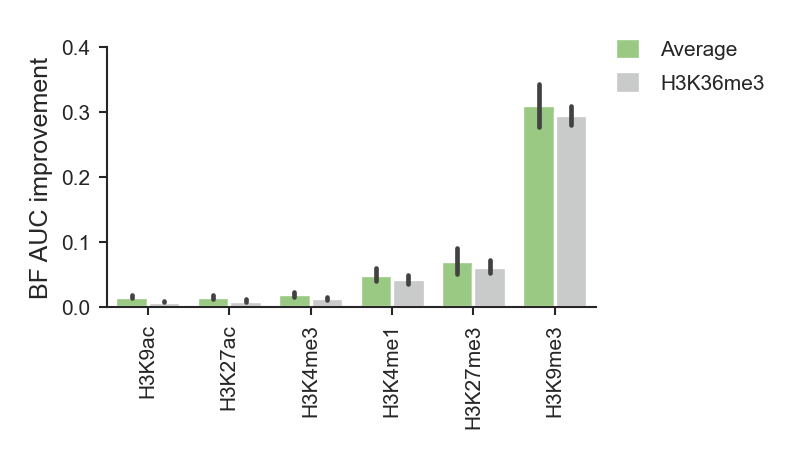

In [37]:
target = 'bf_label'
keep_mark = 'H3K9ac'
data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

# data = data[(data['eid']==eid) & (data['target'] == target) & (data['mark2']==keep_mark)]
data = data[(data['target'] == target)]

data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target[:2]}_para.csv')
data2.columns = ['eid','mark2','fold','auc_single_mark2']

data = pd.merge(data,data2,on = ['eid','mark2','fold'])
data['improvement'] = (data['auc'] - data['auc_single_mark2'])/100

mark1 = 'H3K36me3'
# mark2 = 'H3K27ac'
data = data[data['mark2'] != mark1]
data['is_mark1_combine'] = data.apply(lambda row: mark1 if row['mark1']==mark1 else "Average", axis=1)


data1 = data[data['eid']=='E116']

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(5/2.54, 3.5/2.54))
order = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K27me3','H3K9me3']
palette = [COLOR_MAP['H3K36me3'], "#C9CACA",]
hue_order = ['H3K36me3',"Average"]
sns.barplot(data=data,x='mark2',y='improvement',hue='is_mark1_combine',order=order,hue_order=hue_order,palette=palette,saturation=1)
# ax.set_ylabel(mark2)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.legend().remove()


handles, labels = ax.get_legend_handles_labels()
labels = [ "Average",mark1]
ax.set_xlabel('')
ax.set_ylabel('BF AUC improvement')
ax.set_yticks([i/100 for i in range(0,41,10)])
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(
    handles, labels, 
    loc='upper left',
    title=None ,
    title_fontsize=6, 
    bbox_to_anchor=(0.98, 1.02), 
    fontsize=5,
    ncol=1,
    edgecolor='none',
    handleheight=3/2.54, 
    handlelength=3/2.54,
    handletextpad=1.0,
    labelspacing=1.5/2.54,
    columnspacing=1.5
)
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure3G.eps', format='eps', bbox_inches='tight')

plt.show()


In [33]:
data1

,eid,fold,auc,target,keep_marks,mark1,mark2,auc_single_mark2,improvement,is_mark1_combine
84,E116,0,95.003651,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,93.825101,1.178551,Average
85,E116,1,94.766831,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,93.781885,0.984946,Average
86,E116,2,95.102994,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,92.950420,2.152574,Average
87,E116,3,95.298918,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,93.512924,1.785995,Average
88,E116,0,91.991942,bf_label,H3K4me1_H3K9me3,H3K4me1,H3K9me3,66.529302,25.462639,Average
...,...,...,...,...,...,...,...,...,...,...
407,E116,3,95.581773,bf_label,H3K27me3_H3K9ac,H3K9ac,H3K27me3,91.112973,4.468800,Average
416,E116,0,94.515761,bf_label,H3K27ac_H3K9ac,H3K9ac,H3K27ac,93.673206,0.842555,Average
417,E116,1,94.014486,bf_label,H3K27ac_H3K9ac,H3K9ac,H3K27ac,94.000155,0.014331,Average
418,E116,2,94.783255,bf_label,H3K27ac_H3K9ac,H3K9ac,H3K27ac,94.194630,0.588625,Average


# Figure 4G

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


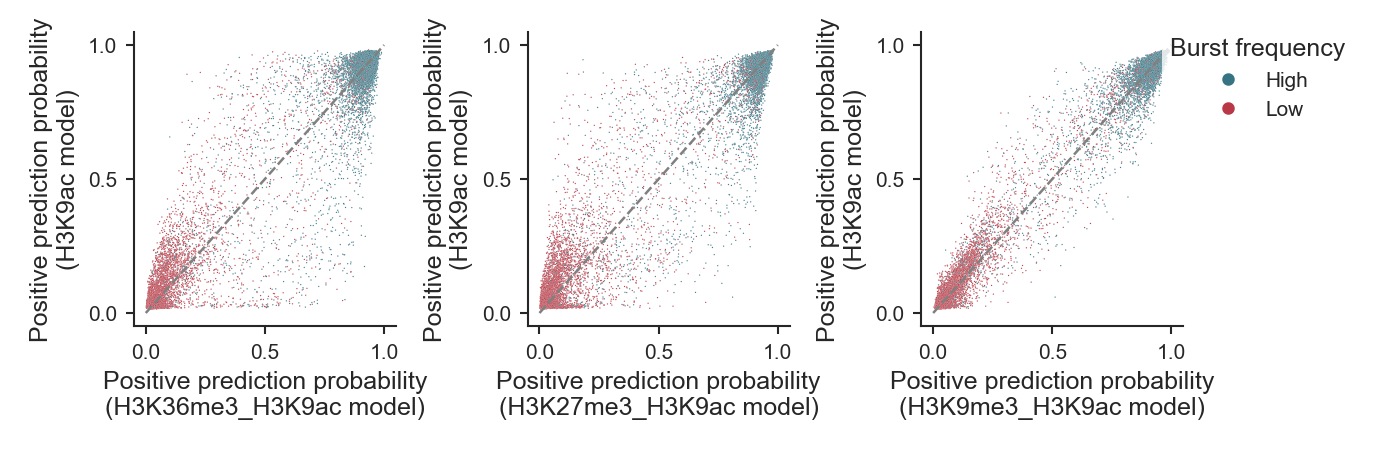

In [4]:
palette = ["#B83945","#377483"]
fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(10/2.54, 3.5/2.54))


eid = 'E116'
mark1 = 'H3K36me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])

sns.scatterplot(data=data,x='score1',y='score2',hue='bf_label_label',s=0.1, ax=ax[0],palette=palette)
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[0])
ax[0].set_ylabel(f'Positive prediction probability\n({mark2} model)',fontsize=6)
ax[0].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[0].set_yticks([i/10 for i in range(0,11,5)])
ax[0].legend().remove()

eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])

sns.scatterplot(data=data,x='score1',y='score2',hue='bf_label_label',s=0.1, ax=ax[1],palette=palette)
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[1])
ax[1].set_ylabel(f'Positive prediction probability\n({mark2} model)',fontsize=6)
ax[1].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
ax[1].set_xticks([i/10 for i in range(0,11,5)])
ax[1].set_yticks([i/10 for i in range(0,11,5)])
ax[1].legend().remove()

eid = 'E116'
mark1 = 'H3K9me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])

sns.scatterplot(data=data,x='score1',y='score2',hue='bf_label_label',s=0.1, ax=ax[2],palette=palette)
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[2])
ax[2].set_ylabel(f'Positive prediction probability\n({mark2} model)',fontsize=6)
ax[2].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
ax[2].set_xticks([i/10 for i in range(0,11,5)])
ax[2].set_yticks([i/10 for i in range(0,11,5)])
ax[2].legend().remove()


import matplotlib.lines as mlines
legend_patches = [
    mlines.Line2D([],[],marker='o', linestyle='None',color=palette[1], markersize=2, label="High"),
    mlines.Line2D([],[],marker='o', linestyle='None',color=palette[0], markersize=2, label="Low"),
]

fig.legend(handles=legend_patches,title='Burst frequency', loc="upper left", bbox_to_anchor=(0.96, 1), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v5/Figure4G.eps', format='eps', bbox_inches='tight')

plt.show()

0.00010677971302338579 3.1529883282262088e-261


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_46561/240374951.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["$BF^-$","$BF^+$"])


4.6355295448359986e-70 3.933829383772785e-257


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_46561/240374951.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["$BF^-$","$BF^+$"])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_46561/240374951.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(["$BF^-$","$BF^+$"])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


0.8763452647204644 2.7767453693195498e-139


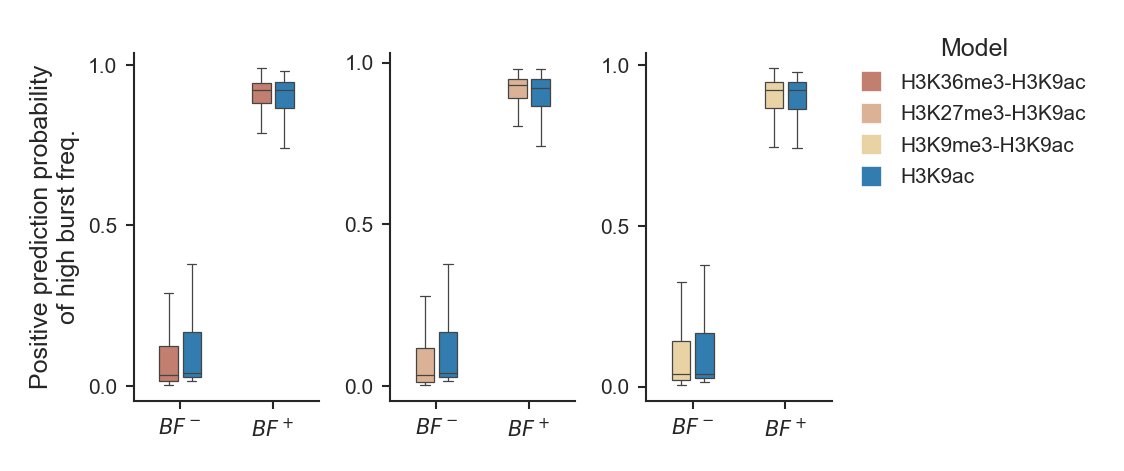

In [4]:
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon


fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))


eid = 'E116'
mark1 = 'H3K36me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)

data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'])


data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'])

print(p_value_pos,p_value_neg)

palette = [COLOR_MAP['H3K36me3'],COLOR_MAP['H3K9ac']]
sns.boxplot(
    data=data,
    x='bf_label_label',
    y='bf_label_score',
    hue='keep_marks',
    fliersize=0,ax=ax[0],
    linewidth=0.3,
    palette=palette,
    saturation=1,
    width=0.5, 
    gap=0.2,
)
ax[0].set_ylabel(f'Positive prediction probability\nof high burst freq.',fontsize=6)
ax[0].set_yticks([i/10 for i in range(0,11,5)])
ax[0].set_xlabel('')
ax[0].legend().remove()
ax[0].set_xticklabels(["$BF^-$","$BF^+$"])



eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)



data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'])


data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'])

print(p_value_pos,p_value_neg)


palette = [COLOR_MAP['H3K27me3'],COLOR_MAP['H3K9ac']]
sns.boxplot(
    data=data,
    x='bf_label_label',
    y='bf_label_score',
    hue='keep_marks',
    fliersize=0,ax=ax[1],
    linewidth=0.3,
    palette=palette,
    saturation=1,
    width=0.5, 
    gap=0.2,
)

ax[1].set_ylabel(f'',fontsize=6)
ax[1].set_yticks([i/10 for i in range(0,11,5)])
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels(["$BF^-$","$BF^+$"])


eid = 'E116'
mark1 = 'H3K9me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)



data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'])


data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'])

print(p_value_pos,p_value_neg)


palette = [COLOR_MAP['H3K9me3'],COLOR_MAP['H3K9ac']]
sns.boxplot(
    data=data,
    x='bf_label_label',
    y='bf_label_score',
    hue='keep_marks',
    fliersize=0,ax=ax[2],
    linewidth=0.3,
    palette=palette,
    saturation=1,
    width=0.5, 
    gap=0.2,
)

ax[2].set_ylabel(f'',fontsize=6)
ax[2].set_yticks([i/10 for i in range(0,11,5)])
ax[2].set_xlabel('')
ax[2].legend().remove()
ax[2].set_xticklabels(["$BF^-$","$BF^+$"])

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=COLOR_MAP['H3K36me3'], label='H3K36me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K27me3'], label='H3K27me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K9me3'], label='H3K9me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K9ac'], label='H3K9ac'),

]

fig.legend(
    handles=legend_patches,
    title="Model",
    loc='upper left', 
    bbox_to_anchor=(1, 1.05),
    title_fontsize=6,
    fontsize=5,
    edgecolor='none',
    handleheight=2/2.54, 
    handlelength=2/2.54,
    handletextpad=1.0,
    labelspacing=1.5/2.54,
)  

plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v5/Figure4G_1.eps', format='eps', bbox_inches='tight')

plt.show()

# Supplementary

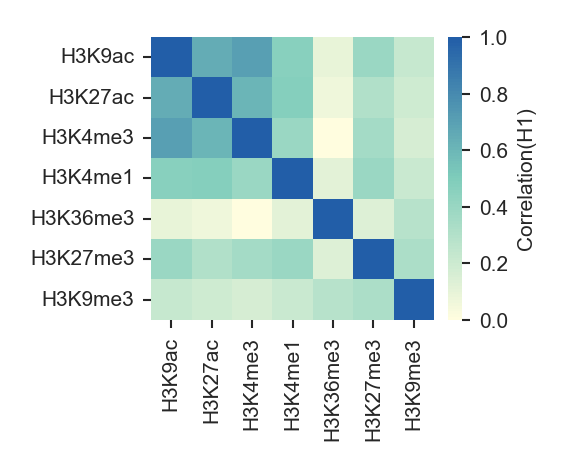

In [10]:
eid = 'E003'
# correlation
correlation = np.loadtxt(f'extra/datasets/benchmark/Promoterformer/results/{eid}_hm_correlation.csv',delimiter=",")
# 选择第 0 个样本的行间相关性矩阵
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4.5/2.54, 4.5/2.54))
ax = sns.heatmap(correlation,cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=0, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100))
ax.set_xticklabels(MARKS,rotation=90)
ax.set_yticklabels(MARKS,rotation=360)
ax.set_aspect('equal')
ax.tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
cbar = ax.collections[0].colorbar

# 调整colorbar的刻度粗细
cbar.ax.tick_params(width=0.5,labelsize=5)  # 设置colorbar刻度的粗细
cbar.set_label(f'Correlation({EIDS_TO_CELLTYPES[eid]})',fontsize=5)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Supplementary_Figure3_1.eps', format='eps', bbox_inches='tight')
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

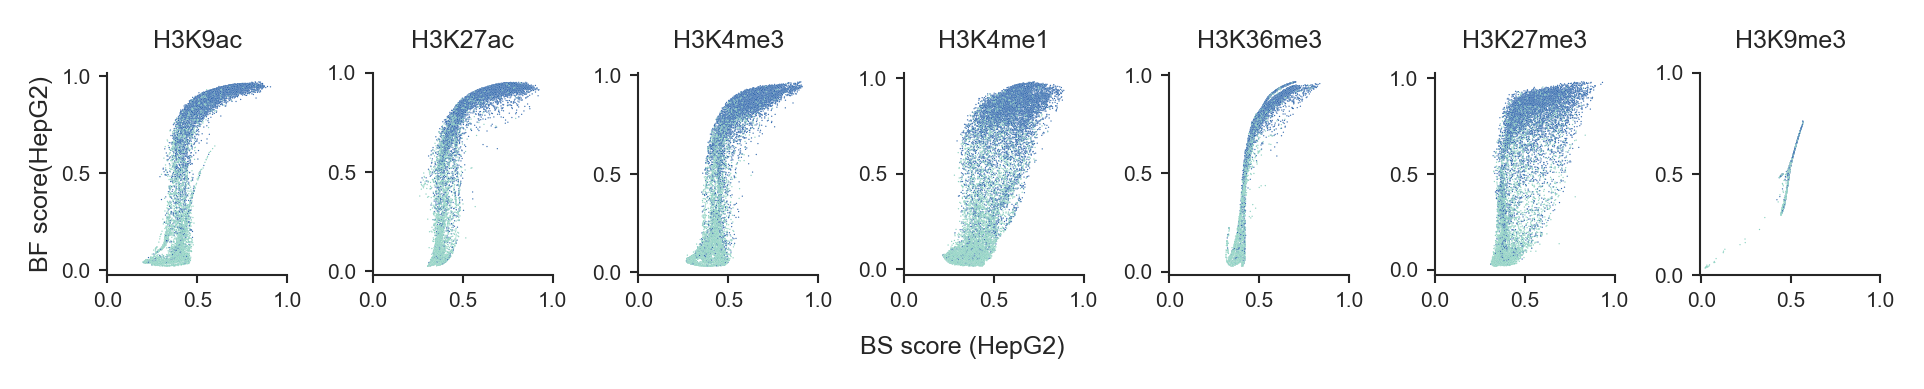

In [26]:
eid='E118'

seed=123
fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(16/2.54, 3/2.54))

for _idx, keep_mark in enumerate(MARKS):
    data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')
    # data = data[data['eid']==eid]
    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
    # keep_mark = 'H3K36me3'
    data = data[(data['keep_marks']==keep_mark) & (data['eid']==eid)]
    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    data = pd.merge(data,meta[['gene_id','mean','mean_label','sc_exp_label','cv_label']], how='inner',on='gene_id')
    # Create the figure and axes


    palette = ["#7FCDBB", "#225EA8"]
    # Create the scatter plot
    sns.scatterplot(
        x=data['bs_label_score'],
        y=data['bf_label_score'],
        hue=data['mean_label'],  # Use 'hue' to map colors
        palette=palette,  # Specify the colormap
        s=0.1,  # Set marker size to 0.1
        legend=False,  # Disable the legend
        ax=ax[_idx]  # Specify the axes to plot on
    )

    # 设置坐标轴
    ax[_idx].set_ylabel('', fontsize=6)
    ax[_idx].set_xlabel('', fontsize=6)
    ax[_idx].set_xticks([i/100 for i in range(0, 101, 50)],labels=[i/100 for i in range(0, 101, 50)])
    ax[_idx].set_yticks([i/100 for i in range(0, 101, 50)],labels=[i/100 for i in range(0, 101, 50)])
    ax[_idx].legend().remove()
    ax[_idx].set_title(keep_mark,fontsize=6,fontweight='regular')

ax[0].set_ylabel(f'BF score({EIDS_TO_CELLTYPES[eid]})', fontsize=6,ha='center')
fig.supxlabel(f'BS score ({EIDS_TO_CELLTYPES[eid]})', fontsize=6,ha='center')
    
# Add a colorbar
import matplotlib.lines as mlines
legend_patches = [
    mlines.Line2D([],[],marker='o', linestyle='None',color="#225EA8", markersize=2, label=1),
    mlines.Line2D([],[],marker='o', linestyle='None',color="#7FCDBB", markersize=2, label=0),
]

# 添加 legend

# fig.legend(handles=legend_patches, title="Expression", loc="upper left", bbox_to_anchor=(0.99, 1), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Supplementary_Figure4A_3.jpg', format='jpg', bbox_inches='tight')

# Show the plot
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/3037522746.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/3037522746.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/3037522746.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/3037522746.py:1

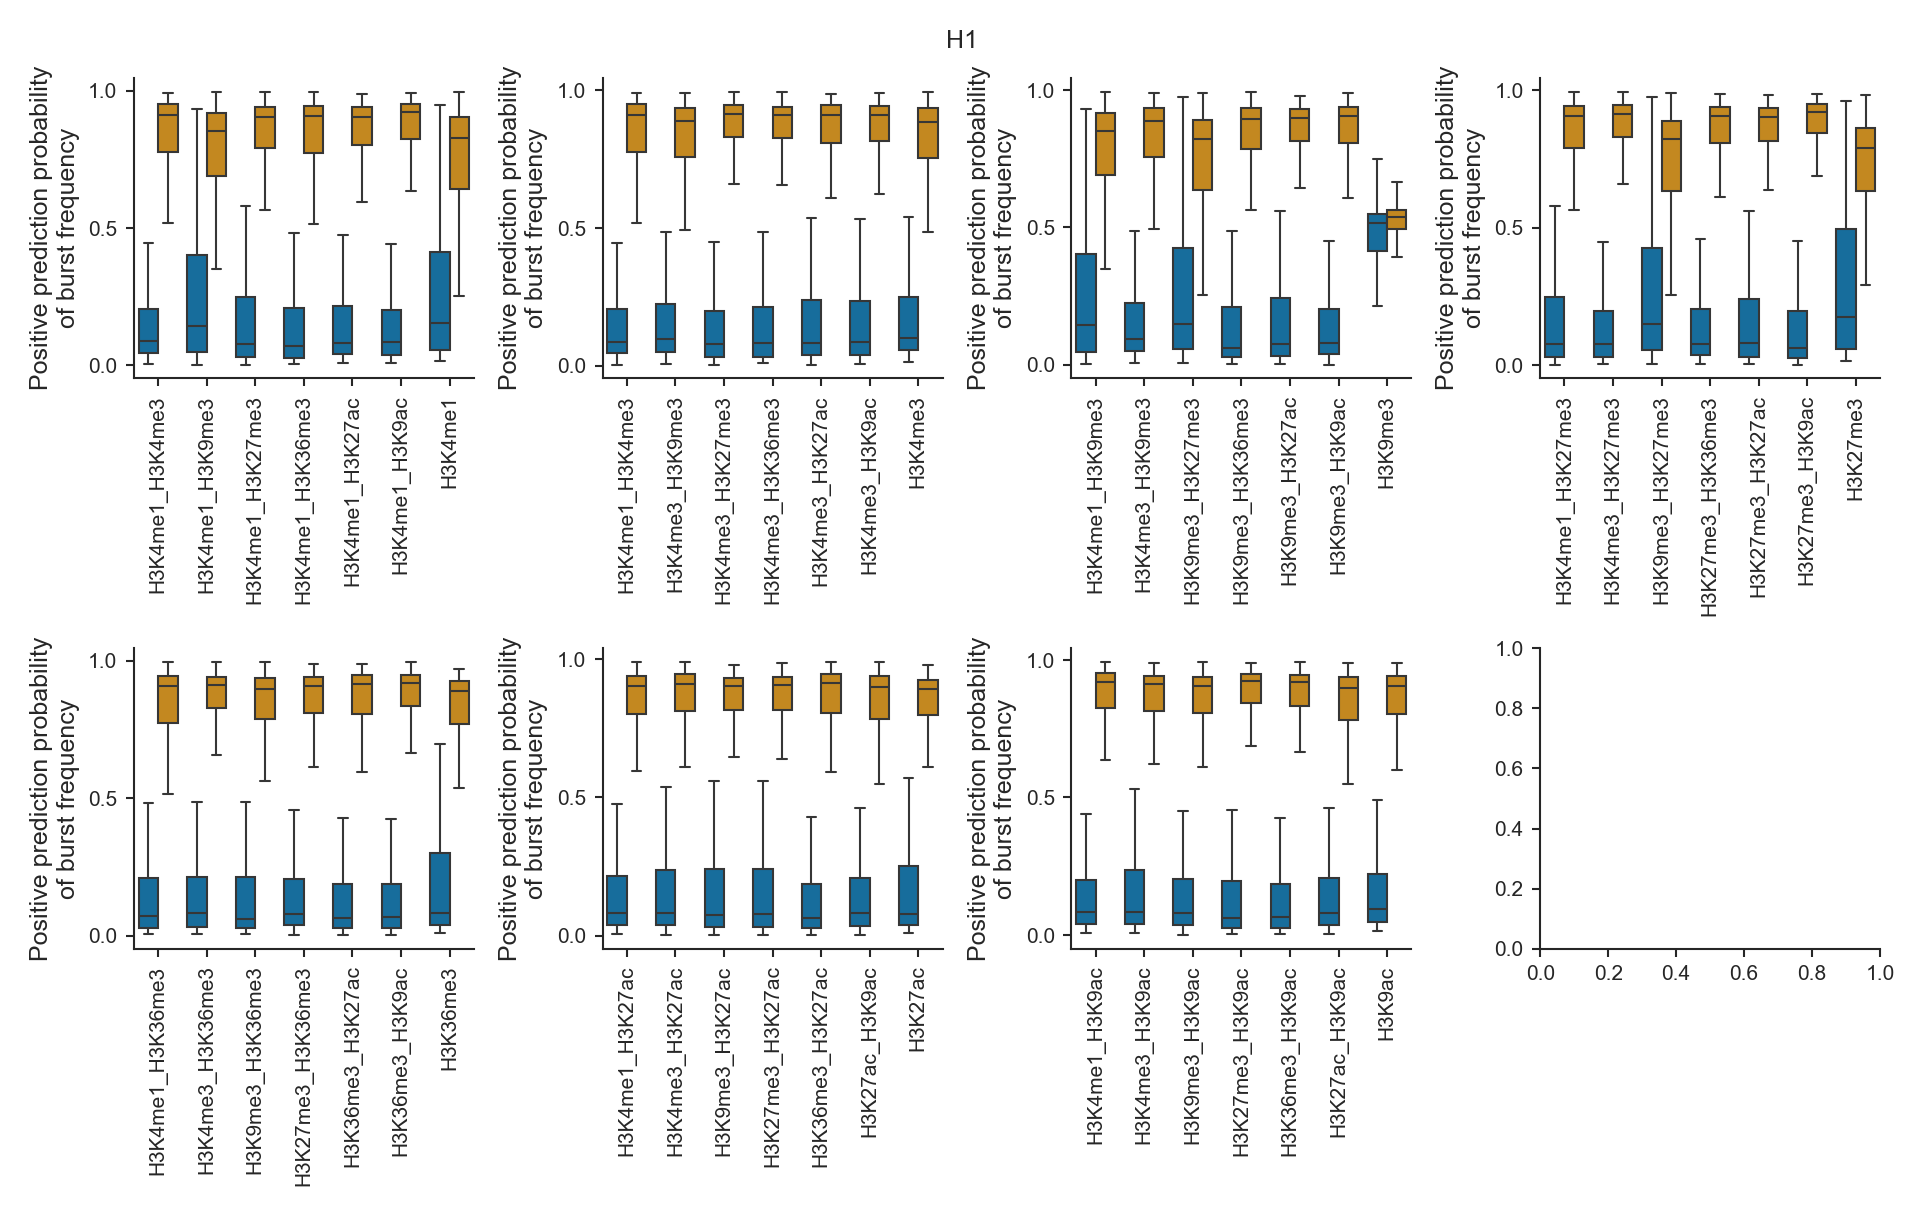

In [28]:
eid = 'E003'
fig, ax = plt.subplots(2,4, constrained_layout=True, figsize=(16/2.54, 10/2.54))

for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
    # data1 = data1[(data1['eid']==eid) & (data1['keep_marks'].str.contains(keep_mark)) ]
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) ]
    data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')
    # data2 = data2[(data2['eid']==eid) & (data2['keep_marks'].str.contains(keep_mark)) ]
    data2 = data2[(data2['keep_marks'].str.contains(keep_mark)) ]

    data = pd.concat([data1,data2],axis=0)
    sns.boxplot(data=data, x='keep_marks',y='bf_label_score',hue='bf_label_label',fliersize=0,ax=ax[_idx // 4, _idx % 4],linewidth=0.5)
    ax[_idx // 4, _idx % 4].set_ylabel(f'Positive prediction probability\nof burst frequency',fontsize=6)

    ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
    ax[_idx // 4, _idx % 4].legend().remove()
    ax[_idx // 4, _idx % 4].set_yticks([i/10 for i in range(0,11,5)])
    ax[_idx // 4, _idx % 4].set_xlabel('')


fig.suptitle(f'{EIDS_TO_CELLTYPES[eid]}')
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v5/Supplementary_figure4D_1.eps', format='eps', bbox_inches='tight')
plt.show()



/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_3004/2756251625.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_3004/2756251625.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


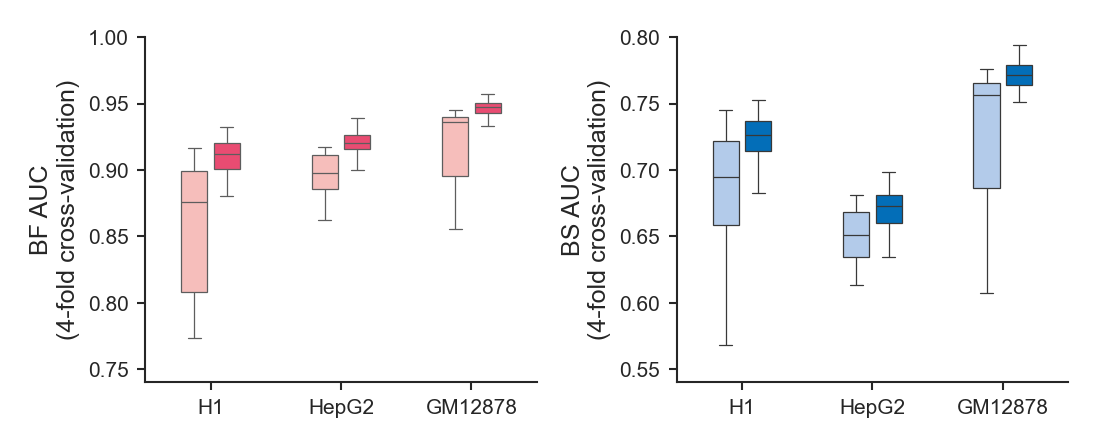

In [3]:
# eid = 'E003'
target = 'bf'
# keep_mark = 'H3K4me3'
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
hue_order = ['single_mark', 'combine_mark']
order = ['E003', 'E118','E116']

data_bf = pd.DataFrame({})
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(9/2.54, 3.5/2.54))
for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid','keep_marks','fold','auc']]
    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark),axis=1)
    data1['type'] = 'combine_mark'

    data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[(data2['keep_mark'] == keep_mark)]
    data2.columns = ['eid','keep_marks','fold','auc']
    data2['type'] = 'single_mark'

    data_bf = pd.concat([data_bf,data1, data2], axis=0)

data_bf['auc'] = data_bf['auc'] / 100
palette = ['#F6BEBB',"#E94C72"]
sns.boxplot(data=data_bf,x='eid',y='auc',hue='type',fliersize=0,linewidth=0.3,gap=0.2,width=0.5,order=order, hue_order=hue_order,palette=palette,ax=ax[0],saturation=1)
ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].set_ylim(bottom=0.74,top=1.0)
ax[0].set_xlabel('')
ax[0].set_ylabel(f'BF AUC\n(4-fold cross-validation)',fontsize=6)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
yticks = [i/100 for i in range(75, 101, 5)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks,labels=yticklabels)

target = 'bs'
data_bs = pd.DataFrame({})
for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid','keep_marks','fold','auc']]
    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark),axis=1)
    data1['type'] = 'combine_mark'

    data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[(data2['keep_mark'] == keep_mark)]
    data2.columns = ['eid','keep_marks','fold','auc']
    data2['type'] = 'single_mark'

    data_bs = pd.concat([data_bs,data1, data2], axis=0)

data_bs['auc'] = data_bs['auc'] / 100


data_bf['target'] = 'bf'
data_bs['target'] = 'bs'
data = pd.concat([data_bf, data_bs], axis=0)

palette = ['#B3CBEA',"#036EB8"]
sns.boxplot(data=data_bs,x='eid',y='auc',hue='type',fliersize=0,linewidth=0.3,gap=0.2,width=0.5,order=order, hue_order=hue_order,palette=palette,ax=ax[1],saturation=1)
# ax[1].set_title(keep_mark)
ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_ylabel(f'BS AUC\n(4-fold cross-validation)',fontsize=6)
ax[1].set_ylim(bottom=0.54,top=0.80)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
yticks = [i/100 for i in range(55, 81, 5)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks,labels=yticklabels)

plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure3D.eps', format='eps', bbox_inches='tight')
plt.show()


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_66649/3455804325.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='keep_marks',y='auc',fliersize=0,linewidth=0.5,order=sorted_keep_marks,palette=palette,ax=ax[_idx // 2, _idx % 2])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_66649/3455804325.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[_idx // 2, _idx % 2].set_xticklabels(ax[_idx // 2, _idx % 2].get_xticklabels(),rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_66649/3455804325.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data

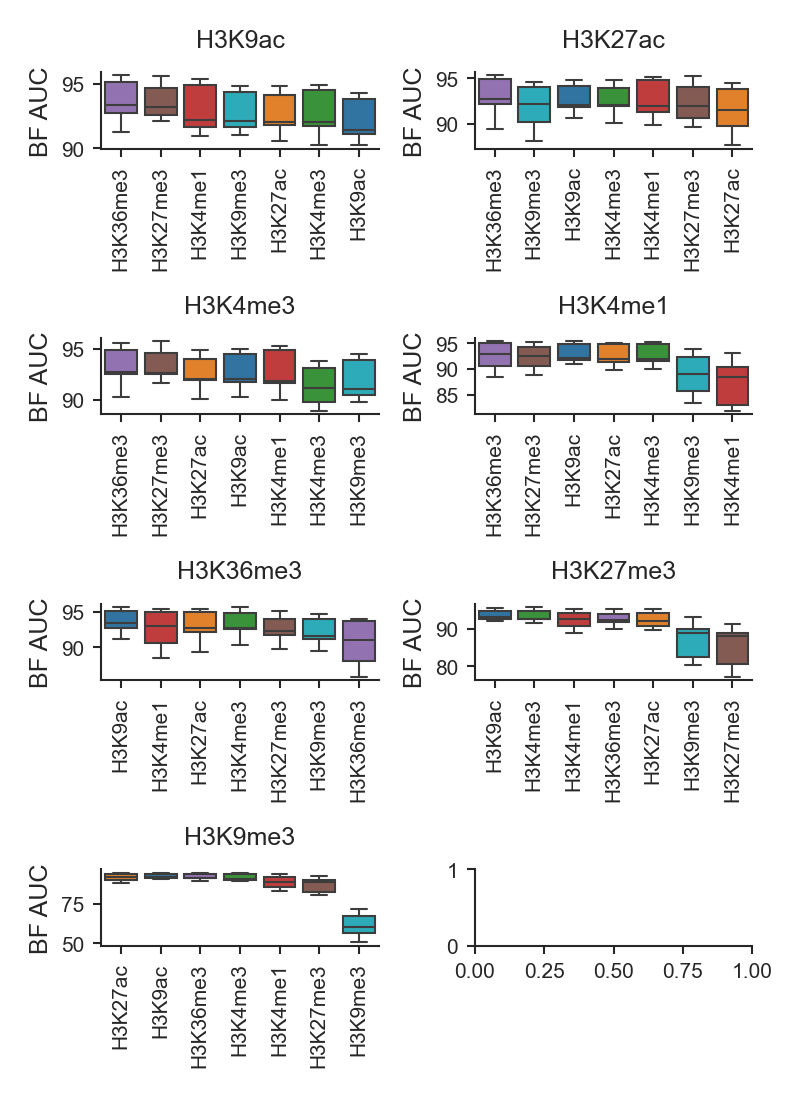

In [26]:
# eid = 'E003'
target = 'bf'
# keep_mark = 'H3K4me3'
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(4,2, constrained_layout=True, figsize=(6.5/2.54, 9/2.54))
for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid','keep_marks','fold','auc']]
    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark),axis=1)

    data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[(data2['keep_mark'] == keep_mark)]
    data2.columns = ['eid','keep_marks','fold','auc']

    data = pd.concat([data1, data2], axis=0)
    data

    sorted_keep_marks = data.groupby('keep_marks')['auc'].median().sort_values(ascending=False).index
    palette = [COLOR_MAP[mark] for mark in sorted_keep_marks]

    sns.boxplot(data=data, x='keep_marks',y='auc',fliersize=0,linewidth=0.5,order=sorted_keep_marks,palette=palette,ax=ax[_idx // 2, _idx % 2])
    ax[_idx // 2, _idx % 2].set_title(keep_mark)
    ax[_idx // 2, _idx % 2].set_xlabel('')
    ax[_idx // 2, _idx % 2].set_ylabel(f'{target.upper()} AUC')
    ax[_idx // 2, _idx % 2].set_xticklabels(ax[_idx // 2, _idx % 2].get_xticklabels(),rotation=90)

plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Supplementary_Figure4_1.eps', format='eps', bbox_inches='tight')
plt.show()


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/3452737200.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels, fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/3452737200.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels, fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/3452737200.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels, fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/3452737200.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklab

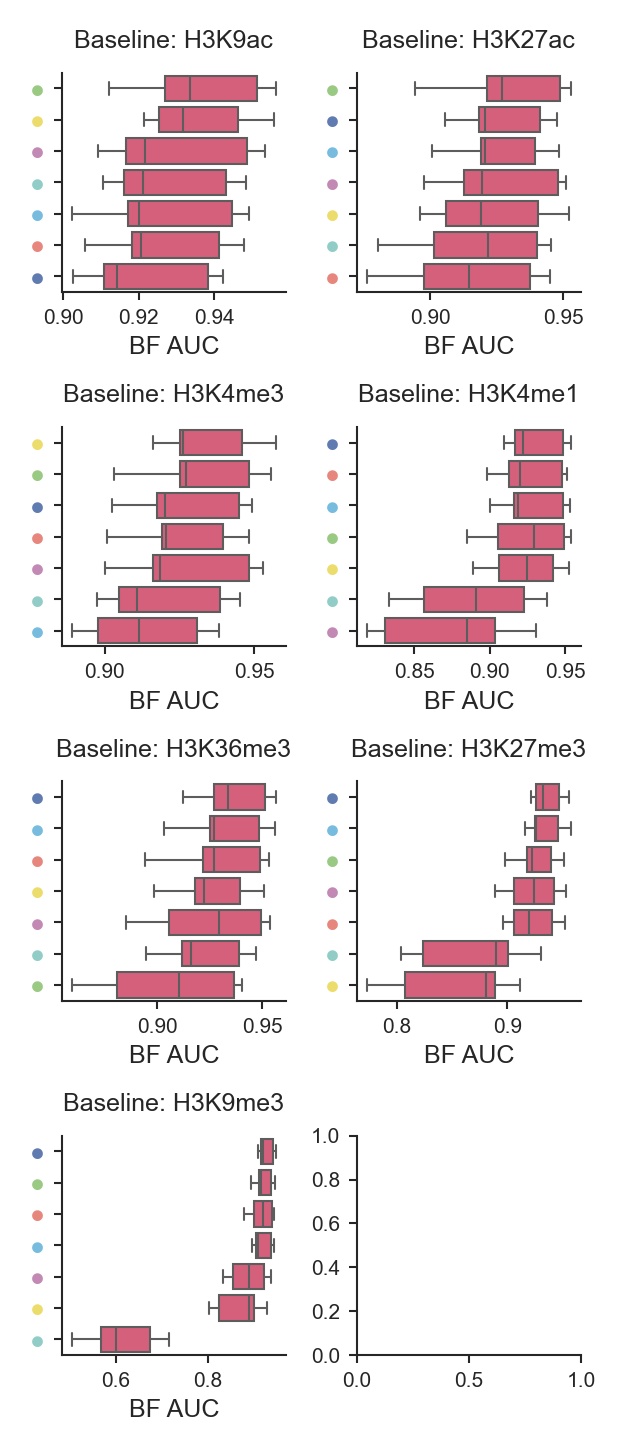

In [38]:
target = 'bf'
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
palette = ['#E94C72','#036EB8']
fig, ax = plt.subplots(4, 2, constrained_layout=True, figsize=(5/2.54, 12/2.54))
for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid','keep_marks','fold','auc']]

    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark), axis=1)

    data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[(data2['keep_mark'] == keep_mark)]
    data2.columns = ['eid','keep_marks','fold','auc']

    data = pd.concat([data1, data2], axis=0)
    data['auc'] = data['auc'] / 100

    # 排序 & 调色
    sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
    # palette = [COLOR_MAP[mark] for mark in sorted_keep_marks]

    ax_sub = ax[_idx // 2, _idx % 2]
    sns.boxplot(
        data=data, y='keep_marks', x='auc',
        fliersize=0, linewidth=0.5,
        order=sorted_keep_marks, color=palette[0], ax=ax_sub, orient='h'
    )

    ax_sub.set_title(f'Baseline: {keep_mark}')
    ax_sub.set_ylabel('')
    ax_sub.set_xlabel(f'{target.upper()} AUC')

    # --- 替换 yticklabels 为彩色竖排圆点 ---
    labels = ax_sub.get_yticklabels()
    for lbl, mark in zip(labels, sorted_keep_marks):
        lbl.set_text("●")          # 用圆点符号
        lbl.set_color(COLOR_MAP[mark])  # 上色
    ax_sub.set_yticklabels(labels, fontsize=6)

plt.savefig(
    'extra/datasets/benchmark/Promoterformer/figures/v6/Supplementary_Figure5_1.eps',
    format='eps', bbox_inches='tight'
)
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/503636381.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels,fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/503636381.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels,fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/503636381.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels,fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74027/503636381.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(lab

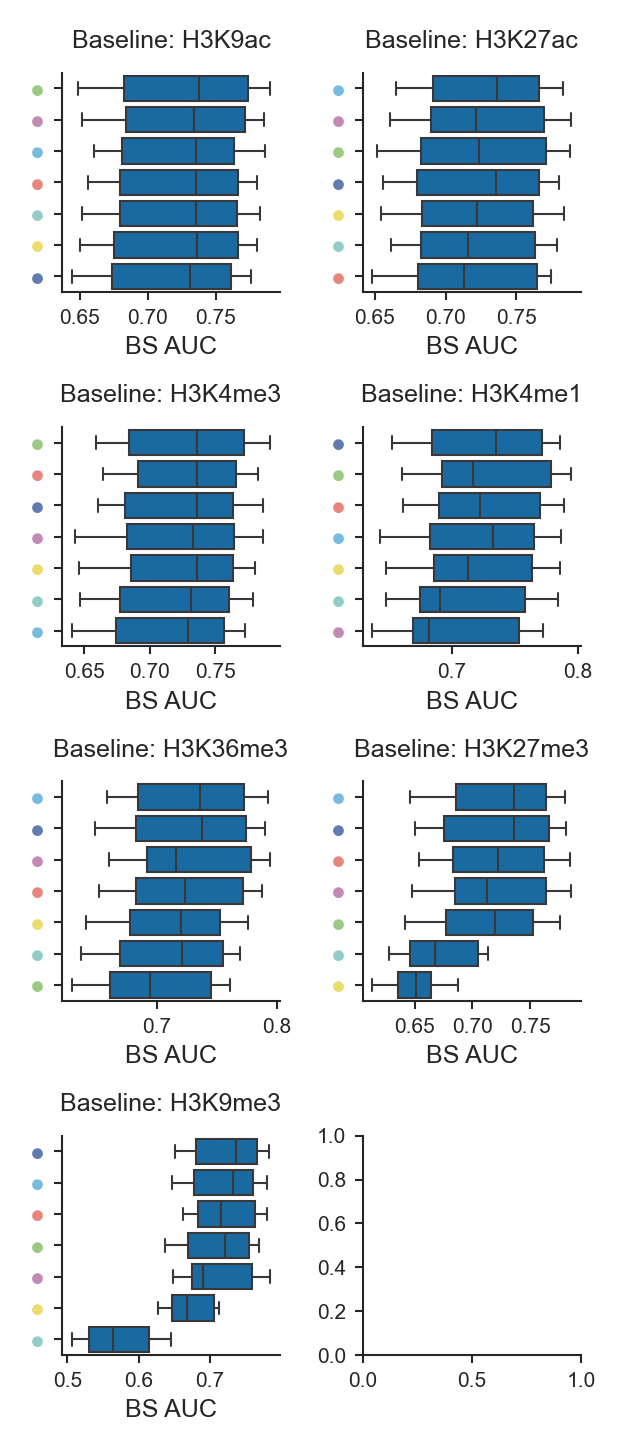

In [39]:
target = 'bs'
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
palette = ['#E94C72','#036EB8']
fig, ax = plt.subplots(4, 2, constrained_layout=True, figsize=(5/2.54, 12/2.54))
for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid','keep_marks','fold','auc']]

    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark), axis=1)

    data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[(data2['keep_mark'] == keep_mark)]
    data2.columns = ['eid','keep_marks','fold','auc']

    data = pd.concat([data1, data2], axis=0)
    data['auc'] = data['auc'] / 100

    # 排序 & 调色
    sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
    # palette = [COLOR_MAP[mark] for mark in sorted_keep_marks]

    ax_sub = ax[_idx // 2, _idx % 2]
    sns.boxplot(
        data=data, y='keep_marks', x='auc',
        fliersize=0, linewidth=0.5,
        order=sorted_keep_marks, color=palette[1], ax=ax_sub, orient='h'
    )

    ax_sub.set_title(f'Baseline: {keep_mark}')
    ax_sub.set_ylabel('')
    ax_sub.set_xlabel(f'{target.upper()} AUC')

    # --- 替换 yticklabels 为彩色竖排圆点 ---
    labels = ax_sub.get_yticklabels()
    for lbl, mark in zip(labels, sorted_keep_marks):
        lbl.set_text("●")          # 用圆点符号
        lbl.set_color(COLOR_MAP[mark])  # 上色
    ax_sub.set_yticklabels(labels,fontsize=6)

plt.savefig(
    'extra/datasets/benchmark/Promoterformer/figures/v6/Supplementary_Figure5_2.eps',
    format='eps', bbox_inches='tight'
)
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/1921764316.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/1921764316.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/1921764316.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9687/1921764316.py:1

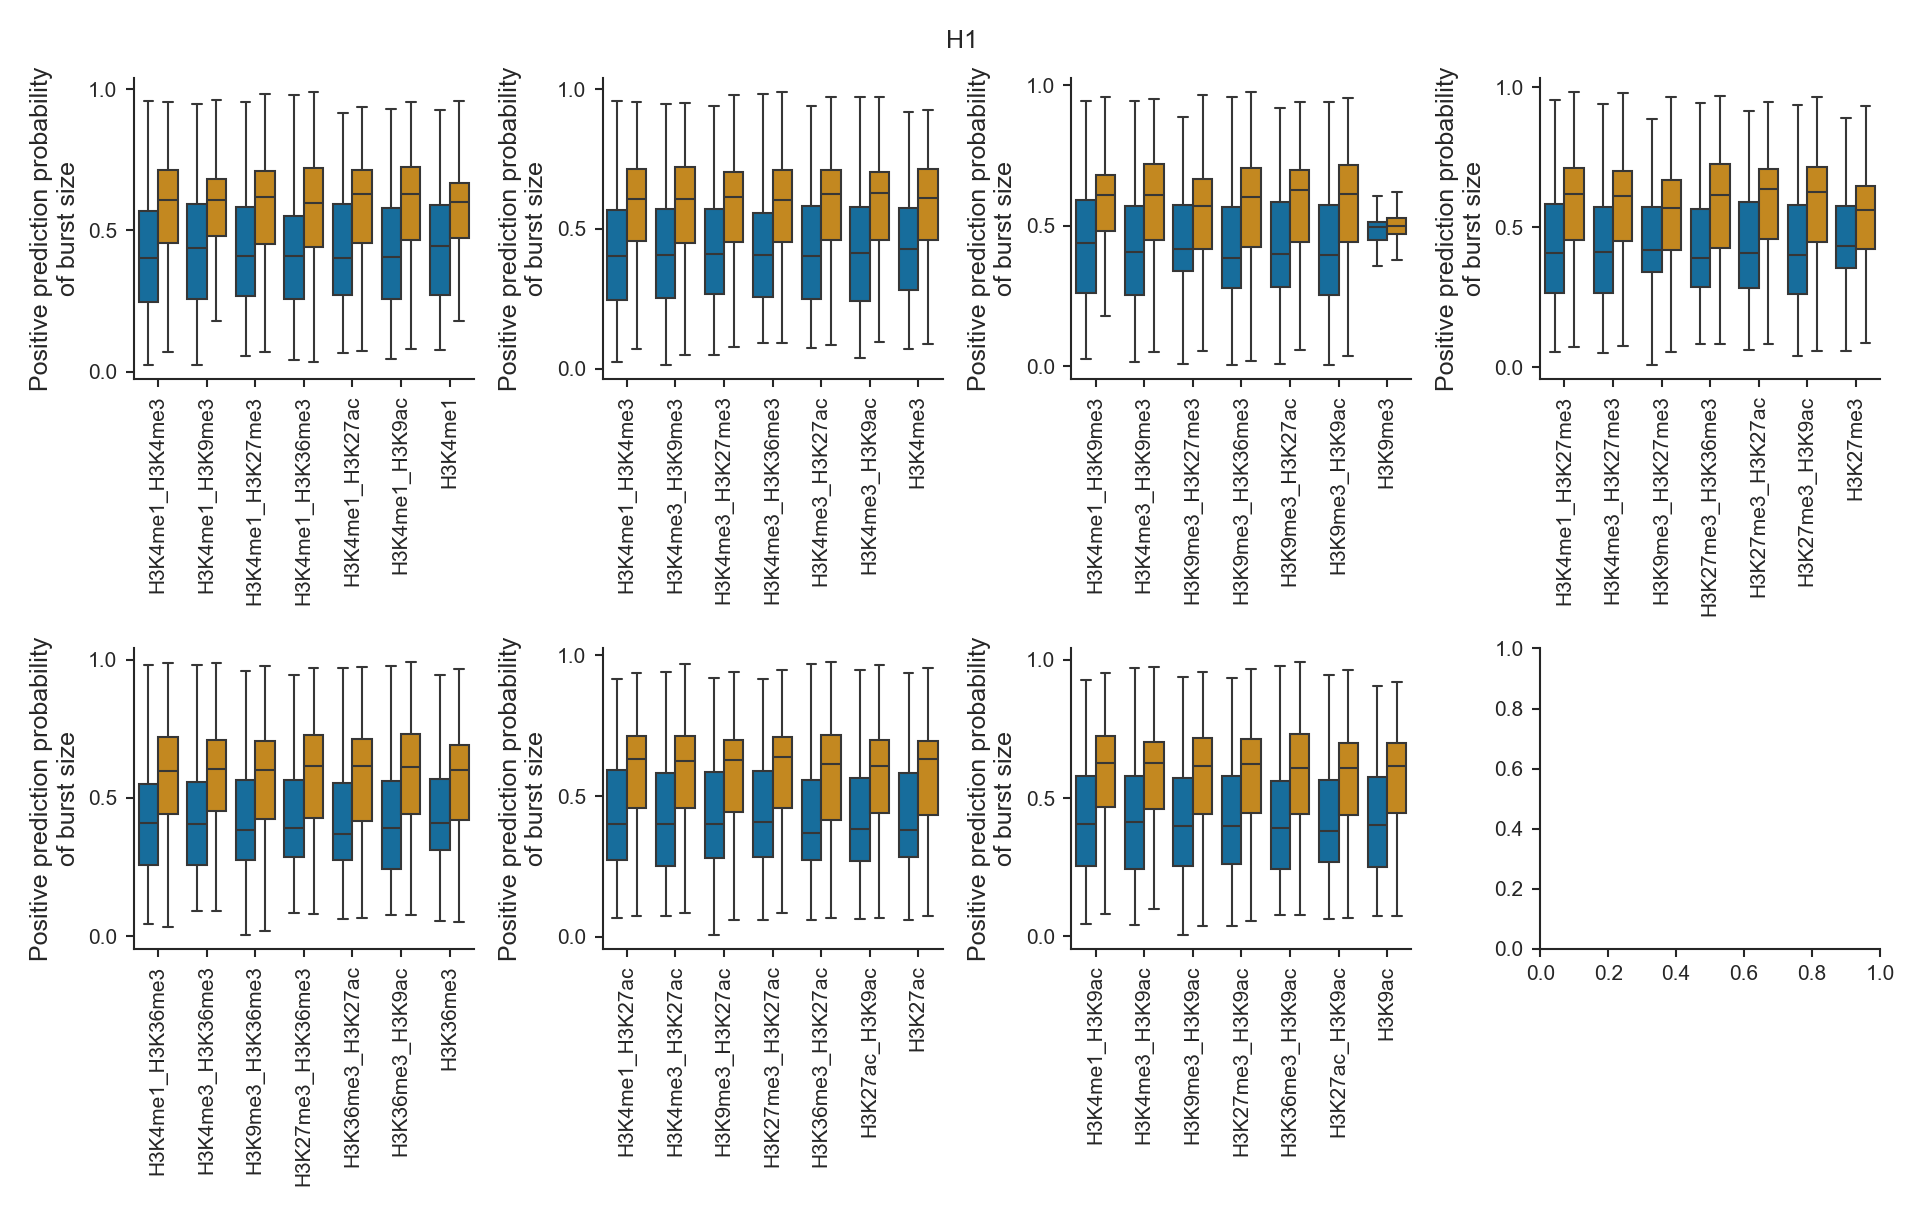

In [29]:
eid = 'E003'
fig, ax = plt.subplots(2,4, constrained_layout=True, figsize=(16/2.54, 10/2.54))

for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/keep_marks_predictions_bs_bf.csv')
    # data1 = data1[(data1['eid']==eid) & (data1['keep_marks'].str.contains(keep_mark)) ]
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) ]
    data2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/single_mark_predictions_bs_bf.csv')
    # data2 = data2[(data2['eid']==eid) & (data2['keep_marks'].str.contains(keep_mark)) ]
    data2 = data2[(data2['keep_marks'].str.contains(keep_mark)) ]

    data = pd.concat([data1,data2],axis=0)
    sns.boxplot(data=data, x='keep_marks',y='bs_label_score',hue='bs_label_label',fliersize=0,ax=ax[_idx // 4, _idx % 4],linewidth=0.5)
    ax[_idx // 4, _idx % 4].set_ylabel(f'Positive prediction probability\nof burst size',fontsize=6)

    ax[_idx // 4, _idx % 4].set_xticklabels(ax[_idx // 4, _idx % 4].get_xticklabels(),rotation=90)
    ax[_idx // 4, _idx % 4].legend().remove()
    ax[_idx // 4, _idx % 4].set_yticks([i/10 for i in range(0,11,5)])
    ax[_idx // 4, _idx % 4].set_xlabel('')

fig.suptitle(f'{EIDS_TO_CELLTYPES[eid]}')
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v5/Supplementary_figure4F_1.eps', format='eps', bbox_inches='tight')

plt.show()
